# Fouls per Yellow Card Analysis
Which teams get punished the most for their fouls? Calculate fouls per yellow card for each team.

In [62]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.patheffects as path_effects
from PIL import Image
import numpy as np

plt.style.use('seaborn-v0_8-white')
DATA_DIR = Path('..') / 'data' / 'processed'
OUTPUT_DIR = Path('..') / 'outputs' / 'final_posts'
FIGURE_DIR = Path('..') / 'outputs' / 'figures'
BKG_IMG_PATH = FIGURE_DIR / 'kaca.jpg'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'

In [63]:
# Load data
team_stats = pd.read_csv(DATA_DIR / 'match_team_statistics.csv')
teams_meta = pd.read_csv(DATA_DIR / 'teams_metadata.csv')

# Clean column names (remove leading/trailing spaces)
teams_meta.columns = teams_meta.columns.str.strip()

# Aggregate fouls and yellow cards per team
team_aggregates = team_stats.groupby('team_id').agg({
    'fouls': 'sum',
    'yellowCards': 'sum'
}).reset_index()

# Calculate fouls per yellow card
team_aggregates['fouls_per_yellow'] = team_aggregates['fouls'] / team_aggregates['yellowCards']

# Merge with team metadata
team_data = team_aggregates.merge(teams_meta[['team_id', 'short_name']], on='team_id')

# Sort by fouls per yellow card ascending (lowest/strictest gets rank 1)
team_data = team_data.sort_values('fouls_per_yellow', ascending=True).reset_index(drop=True)
team_data['rank'] = range(1, len(team_data) + 1)

team_data.head(20)

,team_id,fouls,yellowCards,fouls_per_yellow,short_name,rank
0,36019,265,48,5.520833,Mornar,1
1,5143,275,49,5.612245,Budućnost,2
2,327162,255,41,6.219512,Mladost DG,3
3,6216,253,40,6.325000,Petrovac,4
4,6226,249,33,7.545455,Dečić,5
5,7581,277,33,8.393939,Bokelj,6
6,6219,313,36,8.694444,Jedinstvo,7
7,6224,281,32,8.781250,Sutjeska,8
8,37956,292,27,10.814815,Arsenal Tivat,9
9,24312,259,23,11.260870,Jezero,10


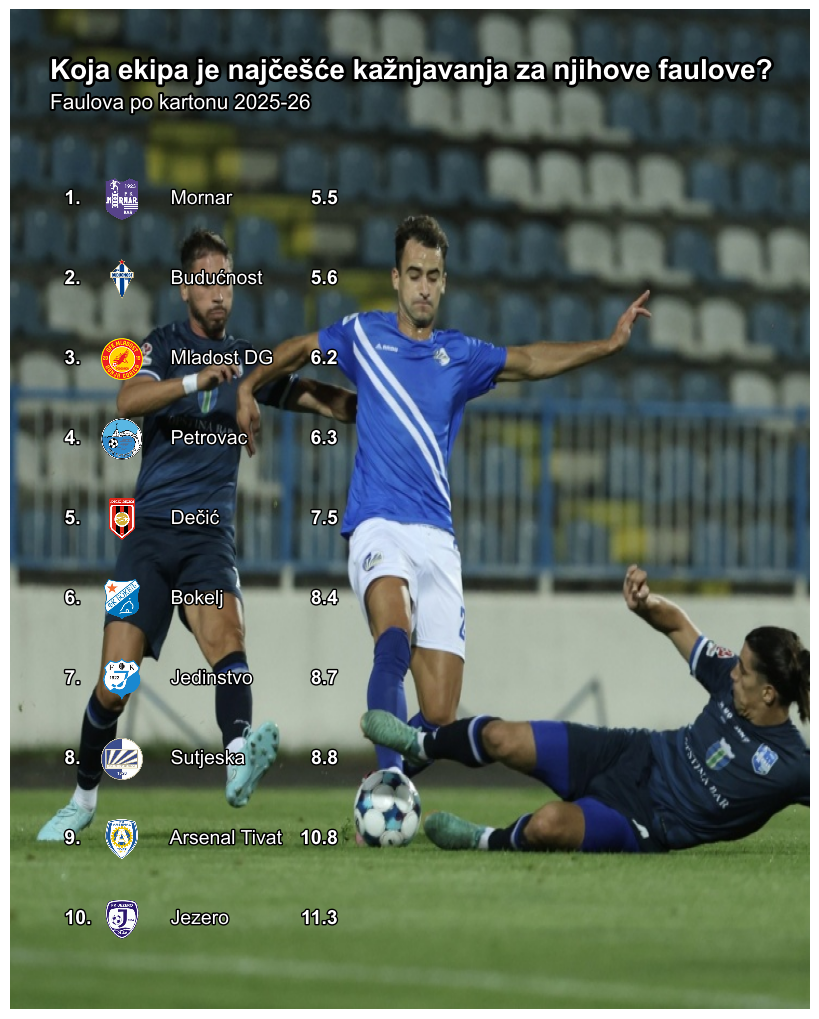

Saved to: ..\outputs\final_posts\fouls_per_yellow.png


In [64]:
# Create visualization
fig_width = 8
fig_height = 10
fig = plt.figure(figsize=(fig_width, fig_height), dpi=100)

# Add background
background_img = plt.imread(BKG_IMG_PATH)
ax_bg = fig.add_axes([0, 0, 1, 1], zorder=-1)
ax_bg.imshow(background_img, aspect='auto', extent=[0, 1, 0, 1])
ax_bg.axis('off')

# Create main axis for the table
ax = fig.add_axes([0.05, 0.05, 0.9, 0.80])
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, len(team_data))

# Title (single line, smaller font)
title = fig.text(0.05, 0.95, 'Koja ekipa je najčešće kažnjavanja za njihove faulove?', 
                 fontsize=20, weight='bold', color='white', 
                 va='top', ha='left')
title.set_path_effects([
    path_effects.Stroke(linewidth=4, foreground='black'),
    path_effects.Normal()
])

subtitle = fig.text(0.05, 0.915, 'Faulova po kartonu 2025-26',
                    fontsize=15, color='white', va='top', ha='left')
subtitle.set_path_effects([
    path_effects.Stroke(linewidth=3, foreground='black'),
    path_effects.Normal()
])

# Draw rows
logo_size = 0.2
y_start = len(team_data) - 0.5

for idx, row in team_data.iterrows():
    y_pos = y_start - idx
    
    # Rank
    rank_text = ax.text(0.02, y_pos, f"{row['rank']}.", 
                       fontsize=14, weight='bold', color='white', 
                       va='center', ha='left')
    rank_text.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])
    
    # Team logo
    logo_path = TEAM_LOGOS_DIR / f"{row['team_id']}.png"
    if logo_path.exists():
        logo_img = Image.open(logo_path).convert('RGBA')
        imagebox = OffsetImage(logo_img, zoom=logo_size)
        ab = AnnotationBbox(imagebox, (0.10, y_pos), frameon=False, 
                           xycoords='data', box_alignment=(0.5, 0.5))
        ax.add_artist(ab)
    
    # Team name
    name_text = ax.text(0.16, y_pos, row['short_name'],
                       fontsize=14, color='white', va='center', ha='left')
    name_text.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])
    
    # Fouls per yellow
    stat_text = ax.text(0.40, y_pos, f"{row['fouls_per_yellow']:.1f}",
                       fontsize=14, weight='bold', color='white', 
                       va='center', ha='right')
    stat_text.set_path_effects([
        path_effects.Stroke(linewidth=2, foreground='black'),
        path_effects.Normal()
    ])

plt.show()

# Save
output_path = OUTPUT_DIR / 'fouls_per_yellow.png'
fig.savefig(output_path, dpi=300, format='png')
plt.close(fig)
print(f'Saved to: {output_path}')